# Ex2 Regression: Moore's Law (number of transistor per sqr inch X2 every two years)

In [1]:
#%pip install pandas

In [2]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## lets understand our data

In [3]:
df  = pd.read_csv('../DATA/moore.csv')

In [4]:
df.head()

,1971,2300
0,1972,3500
1,1973,2500
2,1973,2500
3,1974,4100
4,1974,4500


In [5]:
X,y = df.iloc[:,0].values,df.iloc[:,1].values

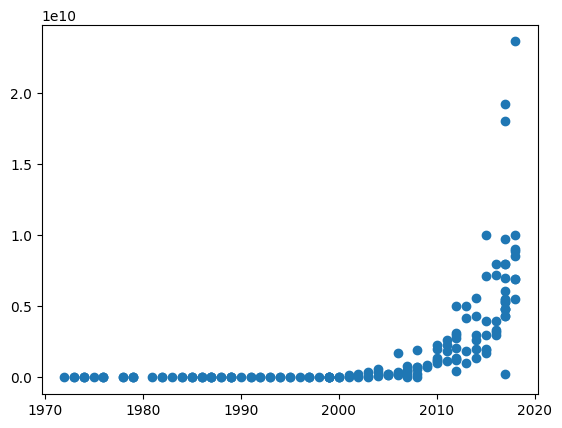

In [6]:
plt.scatter(X,y)

indeed moore law say the plot should be exponential, however if we take log it will be linear

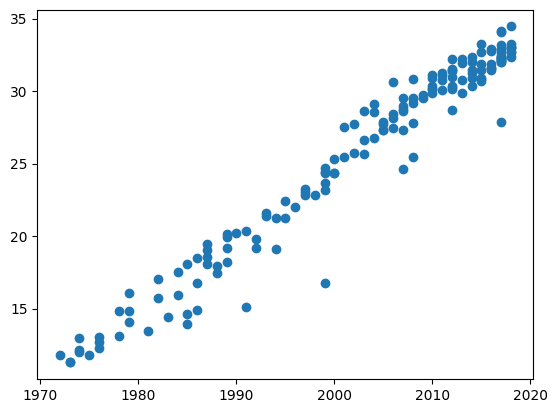

In [7]:
plt.scatter(X,np.log2(y))

now indeed a linear regression model can be used!

## transform the data

In [8]:
X = X.reshape(-1,1)
y = np.log2(y).reshape(-1,1)
print(f'X shape {X.shape} y shape {y.shape} ')
#normalize data
Xstd = X.std()
Xmean = X.mean()
ystd = y.std()
ymean= y.mean()

X= (X-Xmean)/Xstd
y = (y-ymean)/ystd

inputs = torch.from_numpy(X.astype(np.float32)).cuda()
targets = torch.from_numpy(y.astype(np.float32)).cuda()

X shape (161, 1) y shape (161, 1) 


## create the model

In [9]:
model = nn.Linear(X.shape[1],y.shape[1]).cuda()
criterion = nn.MSELoss().cuda()
optimizer = opt.SGD(model.parameters(),lr=0.01,momentum=0.7)



## training 

In [10]:
EPOCHS = 90
losses = []

for epoch in range(EPOCHS): 
    optimizer.zero_grad()

    predictions = model(inputs)
    loss = criterion(predictions,targets)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    print(f'{epoch+1}/{EPOCHS} loss: {loss.item()}')

1/90 loss: 0.9746120572090149
2/90 loss: 0.9375797510147095
3/90 loss: 0.8770498037338257
4/90 loss: 0.8035991191864014
5/90 loss: 0.7249332666397095
6/90 loss: 0.6463356018066406
7/90 loss: 0.5711983442306519
8/90 loss: 0.501515805721283
9/90 loss: 0.43829241394996643
10/90 loss: 0.38186100125312805
11/90 loss: 0.3321196138858795
12/90 loss: 0.2887018024921417
13/90 loss: 0.251095712184906
14/90 loss: 0.21872420608997345
15/90 loss: 0.19099722802639008
16/90 loss: 0.167344331741333
17/90 loss: 0.14723335206508636
18/90 loss: 0.13018013536930084
19/90 loss: 0.11575194448232651
20/90 loss: 0.10356707870960236
21/90 loss: 0.09329232573509216
22/90 loss: 0.08463914692401886
23/90 loss: 0.07735925167798996
24/90 loss: 0.07123997062444687
25/90 loss: 0.06609999388456345
26/90 loss: 0.061785195022821426
27/90 loss: 0.058164916932582855
28/90 loss: 0.05512860044836998
29/90 loss: 0.05258296802639961
30/90 loss: 0.05044933781027794
31/90 loss: 0.04866144433617592
32/90 loss: 0.0471635796129703

## plot losses

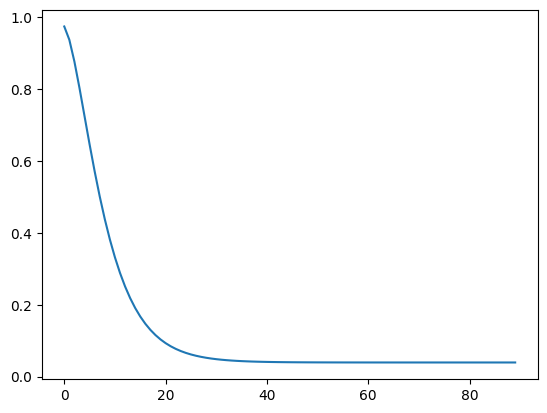

In [11]:
plt.plot(losses)

In [12]:
predictions =None
with torch.no_grad():
    predictions = model(inputs).cpu().numpy()

print(predictions)

[[-2.2113724 ]
 [-2.138594  ]
 [-2.138594  ]
 [-2.0658157 ]
 [-2.0658157 ]
 [-2.0658157 ]
 [-1.9930372 ]
 [-1.9202588 ]
 [-1.9202588 ]
 [-1.9202588 ]
 [-1.774702  ]
 [-1.774702  ]
 [-1.7019236 ]
 [-1.7019236 ]
 [-1.7019236 ]
 [-1.5563667 ]
 [-1.4835883 ]
 [-1.4835883 ]
 [-1.4108099 ]
 [-1.3380315 ]
 [-1.3380315 ]
 [-1.2652532 ]
 [-1.2652532 ]
 [-1.2652532 ]
 [-1.1924747 ]
 [-1.1924747 ]
 [-1.1924747 ]
 [-1.1196964 ]
 [-1.1196964 ]
 [-1.1196964 ]
 [-1.1196964 ]
 [-1.0469178 ]
 [-1.0469178 ]
 [-0.9741395 ]
 [-0.9741395 ]
 [-0.9741395 ]
 [-0.9741395 ]
 [-0.90136105]
 [-0.8285827 ]
 [-0.8285827 ]
 [-0.7558043 ]
 [-0.7558043 ]
 [-0.6830259 ]
 [-0.6830259 ]
 [-0.61024743]
 [-0.61024743]
 [-0.5374691 ]
 [-0.24635546]
 [-0.5374691 ]
 [-0.4646907 ]
 [-0.39191225]
 [-0.39191225]
 [-0.39191225]
 [-0.31913388]
 [-0.24635546]
 [-0.24635546]
 [-0.17357706]
 [-0.17357706]
 [-0.24635546]
 [-0.24635546]
 [-0.24635546]
 [-0.17357706]
 [-0.10079866]
 [-0.10079866]
 [-0.02802025]
 [ 0.11753655]
 [ 0.11753

let's revert the normalization

In [13]:
w = model.weight.detach().cpu().numpy()
b = model.bias.detach().cpu().numpy()

print(f'y={w}x+{b}')

y=[[0.9800291]]x+[0.00045825]


In [14]:
X = X*Xstd+Xmean
y = y*ystd+ymean
predictions = predictions*ystd+ymean

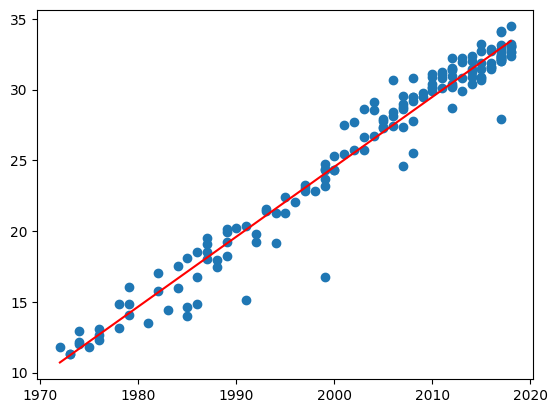

In [15]:
plt.scatter(X,y)
plt.plot(X,predictions,color='red')

[[2025]]


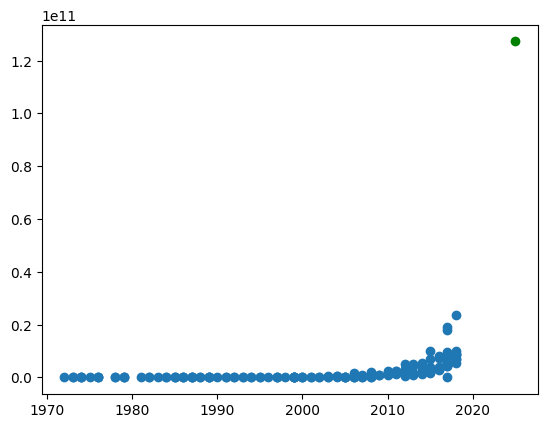

In [16]:
#single point prediction
a = np.asarray([2025])
a = a.reshape(-1,1)
print(a)
a = (a-Xmean) / Xstd
singleinput = torch.from_numpy(a.astype(np.float32)).cuda()
with torch.no_grad():
    out = model(singleinput).cpu().numpy()
    out = out*ystd+ymean
    a = a*Xstd + Xmean
    plt.scatter(X,np.exp2(y))
    plt.scatter(a,np.exp2(out),color='green')